In [63]:
import pandas as pd
from pathlib import Path

# Dataset + Metadata Loading & Overview


In [64]:
BASE = Path("../data/raw")

# Meta data incelicez ilk önce, iç yapısını ve sütunların ne anlama geldiğini anlamak için.
meta_data_df = pd.read_csv(BASE / "all_metadata.csv")

print("Shape:", meta_data_df.shape)
print("Columns:", meta_data_df.columns.tolist())
print("Dtypes:", meta_data_df.dtypes.tolist())
print("Head:")
meta_data_df.head()

Shape: (1920, 13)
Columns: ['Variant_name', 'Run_Batch', 'Variant_path', 'date_created', 'date_loaded', 'FSW_rows', 'Simulation_columns', 'FSW_columns', 'Scenario', 'Month', 'Time_offset', 'Description', 'data_file']
Dtypes: [dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O'), dtype('float64'), dtype('O'), dtype('O')]
Head:


,Variant_name,Run_Batch,Variant_path,date_created,date_loaded,FSW_rows,Simulation_columns,FSW_columns,Scenario,Month,Time_offset,Description,data_file
0,1_0.0_0,Firesat_Baseline,Firesat_Baseline/FireSat_baseline_updated_1_0....,2025-08-29T03:54:34.216196,2025-08-29T03:54:45.984822,602,69,134,baseline,January,0.0,Firesat_Baseline January Time Offset:0.0,./data/raw/baseline/fsw_data_1_0.0_0.csv
1,1_36.0_0,Firesat_Baseline,Firesat_Baseline/FireSat_baseline_updated_1_36...,2025-08-29T03:54:46.089648,2025-08-29T03:54:58.827963,602,69,134,baseline,January,36.0,Firesat_Baseline January Time Offset:36.0,./data/raw/baseline/fsw_data_1_36.0_0.csv
2,1_72.0_0,Firesat_Baseline,Firesat_Baseline/FireSat_baseline_updated_1_72...,2025-08-29T03:54:58.928442,2025-08-29T03:55:11.794282,602,69,134,baseline,January,72.0,Firesat_Baseline January Time Offset:72.0,./data/raw/baseline/fsw_data_1_72.0_0.csv
3,1_108.0_0,Firesat_Baseline,Firesat_Baseline/FireSat_baseline_updated_1_10...,2025-08-29T03:55:11.900084,2025-08-29T03:55:23.651383,602,69,134,baseline,January,108.0,Firesat_Baseline January Time Offset:108.0,./data/raw/baseline/fsw_data_1_108.0_0.csv
4,1_144.0_0,Firesat_Baseline,Firesat_Baseline/FireSat_baseline_updated_1_14...,2025-08-29T03:55:23.744846,2025-08-29T03:55:35.496401,602,69,134,baseline,January,144.0,Firesat_Baseline January Time Offset:144.0,./data/raw/baseline/fsw_data_1_144.0_0.csv


In [65]:
print("Tail:")
meta_data_df.tail()

Tail:


,Variant_name,Run_Batch,Variant_path,date_created,date_loaded,FSW_rows,Simulation_columns,FSW_columns,Scenario,Month,Time_offset,Description,data_file
1915,12_324.0_-50,Firesat_Attack_RWC,Firesat_Attack_RWC/FireSat_updated_12_324.0_-5...,2025-08-29T02:49:55.770782,2025-08-29T02:50:07.523443,602,69,134,attack_rwc,December,324.0,Firesat_Attack_RWC December Time Offset:324.0,./data/raw/attack_rwc/fsw_data_12_324.0_-50.csv
1916,12_324.0_-25,Firesat_Attack_RWC,Firesat_Attack_RWC/FireSat_updated_12_324.0_-2...,2025-08-29T02:50:07.622140,2025-08-29T02:50:19.391689,602,69,134,attack_rwc,December,324.0,Firesat_Attack_RWC December Time Offset:324.0,./data/raw/attack_rwc/fsw_data_12_324.0_-25.csv
1917,12_324.0_0,Firesat_Attack_RWC,Firesat_Attack_RWC/FireSat_updated_12_324.0_0....,2025-08-29T02:50:19.488263,2025-08-29T02:50:31.228495,602,69,134,attack_rwc,December,324.0,Firesat_Attack_RWC December Time Offset:324.0,./data/raw/attack_rwc/fsw_data_12_324.0_0.csv
1918,12_324.0_25,Firesat_Attack_RWC,Firesat_Attack_RWC/FireSat_updated_12_324.0_25...,2025-08-29T02:50:31.327610,2025-08-29T02:50:43.073062,602,69,134,attack_rwc,December,324.0,Firesat_Attack_RWC December Time Offset:324.0,./data/raw/attack_rwc/fsw_data_12_324.0_25.csv
1919,12_324.0_50,Firesat_Attack_RWC,Firesat_Attack_RWC/FireSat_updated_12_324.0_50...,2025-08-29T02:50:43.180588,2025-08-29T02:50:54.919491,602,69,134,attack_rwc,December,324.0,Firesat_Attack_RWC December Time Offset:324.0,./data/raw/attack_rwc/fsw_data_12_324.0_50.csv


In [67]:
# FSW Row metadata içerisindeki 1920 csv dosyasının her birinde kaç satır olduğunu yani her bir csv dosyasının kaç example içerdiğini göseriyor. 1hz sıklıkla kaydedilen yani saniyede bir kaydedilen 10 dakikalık veriler oldukları için hepsinde 60 * 10 + 2 example var. FSW row bunu gösteriyor. 
# Metadata FSW Row:
meta_data_df["FSW_rows"].value_counts()

# Görüldüğü üzere 2 csv dosyasında anormallik var, yani 2 csv dosyasında diğerlerinin aksine 602 satır yok. EDA adımında olduğumuz için müdahele yok ama bu anormalliği kafamızda not aldık.

FSW_rows
602    1918
510       1
341       1
Name: count, dtype: int64

In [68]:
# FSW Column da metadata içerisindeki 1920 csv dosyasının her birinde kaç feature olduğunu gösteriyor, 600 örneğin feature sayısını veriyor yani.
# Metadata FSW Columns:
meta_data_df["FSW_columns"].value_counts()
# Görüldüğü üzere burada da bazı csv dosyalarında column dengesizliği var, bunlara da ileride bakmak için not aldık.

FSW_columns
134    1726
127     192
90        2
Name: count, dtype: int64

In [71]:
# Then we have the data files themselves. We can reach them by using the paths in the metadata "data_file" column.
#örnek baseline csv dosyası içeriği:
sample_baseline_df = pd.read_csv(BASE / "baseline/fsw_data_1_72.0_0.csv")
sample_baseline_df.head()

# bu şekilde metadata üzerinden data file'lara erişebiliyoruz.

,FswTime(sec),CurrentYear(year),CurrentMonth(month),CurrentDay(day),CurrentHour(hour),CurrentMinute(min),CurrentSecond(sec),Latitude(rad),Longitude(rad),Altitude(m),...,Run_Batch,date_loaded,date_created,UTC,Longitude(deg),Latitude(deg),TimeDelay,Scenario,Run_Batch_Variant,result_label
0,59,2025,1,0,12,19,14,1.27909,-2.33570,900032,...,Firesat_Baseline,2025-08-29 03:55:11.682,2025-08-29 03:55:11.548,2069-12-25 12:18:56,-133.825752,73.286459,72.0,baseline,Firesat_Baseline_1_72.0_0,baseline
1,60,2025,1,0,12,19,15,1.27998,-2.33750,900029,...,Firesat_Baseline,2025-08-29 03:55:11.682,2025-08-29 03:55:11.548,2069-12-25 12:18:57,-133.928885,73.337452,72.0,baseline,Firesat_Baseline_1_72.0_0,baseline
2,61,2025,1,0,12,19,16,1.28087,-2.33930,900029,...,Firesat_Baseline,2025-08-29 03:55:11.682,2025-08-29 03:55:11.548,2069-12-25 12:18:58,-134.032017,73.388445,72.0,baseline,Firesat_Baseline_1_72.0_0,baseline
3,62,2025,1,0,12,19,17,1.28175,-2.34112,900028,...,Firesat_Baseline,2025-08-29 03:55:11.682,2025-08-29 03:55:11.548,2069-12-25 12:18:59,-134.136295,73.438865,72.0,baseline,Firesat_Baseline_1_72.0_0,baseline
4,63,2025,1,0,12,19,18,1.28264,-2.34295,900024,...,Firesat_Baseline,2025-08-29 03:55:11.682,2025-08-29 03:55:11.548,2069-12-25 12:19:00,-134.241147,73.489859,72.0,baseline,Firesat_Baseline_1_72.0_0,baseline


In [72]:
for col in sample_baseline_df.columns:
    print(f"{col} ({sample_baseline_df[col].dtype}): {sample_baseline_df[col].values[:5]})")
    # burada örnek baseline csv dosyasına ait  her bir column ve içlerindeki ilk 5 örneği yazdırdım.

FswTime(sec) (int64): [59 60 61 62 63])
CurrentYear(year) (int64): [2025 2025 2025 2025 2025])
CurrentMonth(month) (int64): [1 1 1 1 1])
CurrentDay(day) (int64): [0 0 0 0 0])
CurrentHour(hour) (int64): [12 12 12 12 12])
CurrentMinute(min) (int64): [19 19 19 19 19])
CurrentSecond(sec) (int64): [14 15 16 17 18])
Latitude(rad) (float64): [1.27909 1.27998 1.28087 1.28175 1.28264])
Longitude(rad) (float64): [-2.3357  -2.3375  -2.3393  -2.34112 -2.34295])
Altitude(m) (int64): [900032 900029 900029 900028 900024])
RawPrimaryGenericPointData[0]() (float64): [76.5311 76.5311 76.5311 76.5311 76.5311])
RawPrimaryGenericPointData[1]() (float64): [-68.5336 -68.5336 -68.5336 -68.5336 -68.5336])
RawPrimaryGenericPointData[2]() (float64): [102. 102. 102. 102. 102.])
RawSecondaryGenericPointData[0]() (float64): [0. 0. 0. 0. 0.])
RawSecondaryGenericPointData[1]() (float64): [0. 0. 0. 0. 0.])
RawSecondaryGenericPointData[2]() (float64): [0. 0. 0. 0. 0.])
Q_B_I[0](1) (float64): [0.536503 0.534079 0.531879

In [ ]:
#örnek attack dosyası içeriği
sample_attack_df = pd.read_csv(BASE / "attack_rwc/fsw_data_12_324.0_0.csv")
sample_attack_df.head()

,FswTime(sec),CurrentYear(year),CurrentMonth(month),CurrentDay(day),CurrentHour(hour),CurrentMinute(min),CurrentSecond(sec),Latitude(rad),Longitude(rad),Altitude(m),...,date_loaded,date_created,UTC,Longitude(deg),Latitude(deg),TimeDelay,AttackIntensity,Scenario,Run_Batch_Variant,result_label
0,59,2025,12,1,13,22,14,-0.564544,-1.49446,900007,...,2025-08-29 02:50:31.122,2025-08-29 02:50:30.999,2071-10-26 13:21:56,-85.626251,-32.345989,324.0,0.0,attack_rwc,Firesat_Attack_RWC_12_324.0_0,baseline
1,60,2025,12,1,13,22,15,-0.563542,-1.49474,900009,...,2025-08-29 02:50:31.122,2025-08-29 02:50:30.999,2071-10-26 13:21:57,-85.642293,-32.288578,324.0,0.0,attack_rwc,Firesat_Attack_RWC_12_324.0_0,baseline
2,61,2025,12,1,13,22,16,-0.562539,-1.49501,900007,...,2025-08-29 02:50:31.122,2025-08-29 02:50:30.999,2071-10-26 13:21:58,-85.657763,-32.231111,324.0,0.0,attack_rwc,Firesat_Attack_RWC_12_324.0_0,baseline
3,62,2025,12,1,13,22,17,-0.561536,-1.49528,900005,...,2025-08-29 02:50:31.122,2025-08-29 02:50:30.999,2071-10-26 13:21:59,-85.673233,-32.173643,324.0,0.0,attack_rwc,Firesat_Attack_RWC_12_324.0_0,baseline
4,63,2025,12,1,13,22,18,-0.560533,-1.49555,900000,...,2025-08-29 02:50:31.122,2025-08-29 02:50:30.999,2071-10-26 13:22:00,-85.688703,-32.116175,324.0,0.0,attack_rwc,Firesat_Attack_RWC_12_324.0_0,baseline


In [ ]:
#örnek attack_rwc csv dosyası içeriği:
for col in sample_attack_rwc_df.columns:
    print(f"{col} ({sample_attack_rwc_df[col].dtype}): {sample_attack_rwc_df[col].values[:5]})")
    # burada örnek attack_rwc csv dosyasına ait  her bir column ve içlerindeki ilk 5 örneği yazdırdım.

FswTime(sec) (int64): [59 60 61 62 63])
CurrentYear(year) (int64): [2025 2025 2025 2025 2025])
CurrentMonth(month) (int64): [12 12 12 12 12])
CurrentDay(day) (int64): [1 1 1 1 1])
CurrentHour(hour) (int64): [13 13 13 13 13])
CurrentMinute(min) (int64): [22 22 22 22 22])
CurrentSecond(sec) (int64): [14 15 16 17 18])
Latitude(rad) (float64): [-0.564544 -0.563542 -0.562539 -0.561536 -0.560533])
Longitude(rad) (float64): [-1.49446 -1.49474 -1.49501 -1.49528 -1.49555])
Altitude(m) (int64): [900007 900009 900007 900005 900000])
RawPrimaryGenericPointData[0]() (float64): [0. 0. 0. 0. 0.])
RawPrimaryGenericPointData[1]() (float64): [0. 0. 0. 0. 0.])
RawPrimaryGenericPointData[2]() (float64): [0. 0. 0. 0. 0.])
RawSecondaryGenericPointData[0]() (float64): [0. 0. 0. 0. 0.])
RawSecondaryGenericPointData[1]() (float64): [0. 0. 0. 0. 0.])
RawSecondaryGenericPointData[2]() (float64): [0. 0. 0. 0. 0.])
Q_B_I[0](1) (float64): [0.443103 0.42018  0.39567  0.37006  0.343323])
Q_B_I[1](1) (float64): [0.691

# Class Balance

In [ ]:
# Scenario-wise Class Distribution
meta_data_df["Scenario"].value_counts()

Scenario
attack_rwa    600
attack_rwb    600
attack_rwc    600
baseline      120
Name: count, dtype: int64

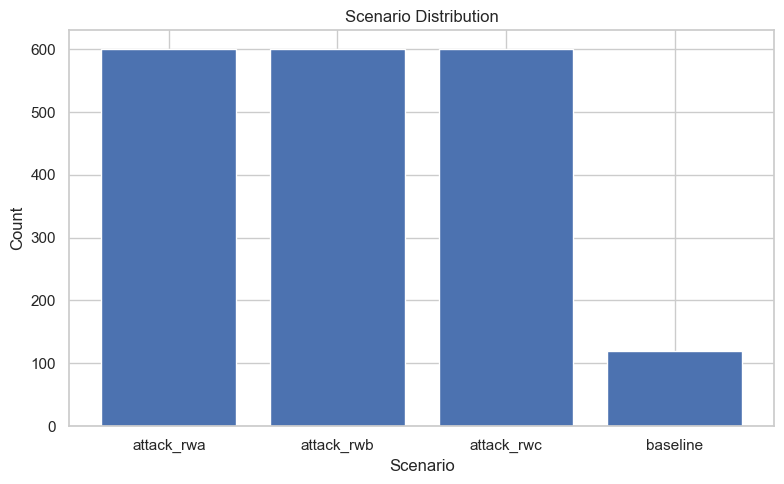

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(meta_data_df["Scenario"].value_counts().index, meta_data_df["Scenario"].value_counts().values)
plt.title("Scenario Distribution")
plt.xlabel("Scenario")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [91]:
all_dfs = []
for _, row in meta_data_df.iterrows():
    file_path = BASE.parent / row["data_file"].replace("./data/raw", "raw")
    df = pd.read_csv(file_path, usecols = ["result_label"])
    all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)

#satır bazlı sınıf dağılımı:
row_counts = combined_df["result_label"].value_counts()


In [92]:
print(row_counts)

result_label
baseline    615840
RWA         180000
RWB         179908
RWC         179739
Name: count, dtype: int64


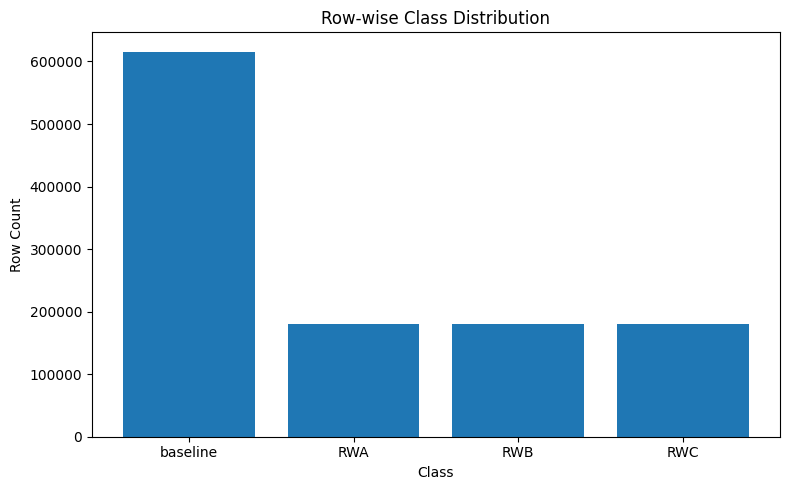

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(row_counts.index, row_counts.values)
plt.title("Row-wise Class Distribution")
plt.xlabel("Class")
plt.ylabel("Row Count")
plt.tight_layout()
plt.show()

# Zaman Ekseninde Görselleştirme

In [139]:
sample_baseline_ts_df = pd.read_csv(BASE / "baseline/fsw_data_1_0.0_0.csv")
sample_attackrwa_ts_df = pd.read_csv(BASE / "attack_rwa/fsw_data_1_0.0_-50.csv")
sample_attackrwb_ts_df = pd.read_csv(BASE / "attack_rwb/fsw_data_1_0.0_-50.csv")
sample_attackrwc_ts_df = pd.read_csv(BASE /  "attack_rwc/fsw_data_1_0.0_-50.csv")


In [140]:
selected_features = ["Q_B_I[0](1)", "Q_B_I[1](1)", "Q_B_I[2](1)", "Q_B_I[3](1)", 
"AttitudeError[0](rad)", "AttitudeError[1](rad)", "AttitudeError[2](rad)",
"AngVel_B_I[0](rad/sec)", "AngVel_B_I[1](rad/sec)", "AngVel_B_I[2](rad/sec)", "AngVelMag_B_I(rad/sec)",
"SensedWheelSpeed__RWA_A(rad/sec)", "SensedWheelSpeed__RWA_B(rad/sec)", "SensedWheelSpeed__RWA_C(rad/sec)",
"WheelCmd__RWA_A(N*m)", "WheelCmd__RWA_B(N*m)", "WheelCmd__RWA_C(N*m)",
"DesiredWheelCommand[0](N*m)", "DesiredWheelCommand[1](N*m)", "DesiredWheelCommand[2](N*m)",
"TotalTorqueRodCommand[0](A*m^2)", "TotalTorqueRodCommand[1](A*m^2)", "TotalTorqueRodCommand[2](A*m^2)",
"BField_B__TAM[0](T)", "BField_B__TAM[1](T)", "BField_B__TAM[2](T)"
]

In [141]:
import seaborn as sns
sns.set_theme(style="whitegrid") 
def plot_features_vs_time(df, title, attack_time = None):
    num_fields = len(selected_features)
    ncols = 3
    nrows = (num_fields + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize=(20, 5 * nrows))
    axes = axes.flatten()

    for i, field in enumerate(selected_features):
        sns.lineplot(data=df, x="FswTime(sec)",y=field, ax=axes[i])

        if attack_time is not None:
            axes[i].axvline(x=attack_time, color="r", linestyle="--", label="Attack Start")
            axes[i].legend(fontsize = 7)

        axes[i].set_title(f"{field} vs FswTime(sec)")
        axes[i].set_xlabel("FswTime(sec)")
        axes[i].set_ylabel(field)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

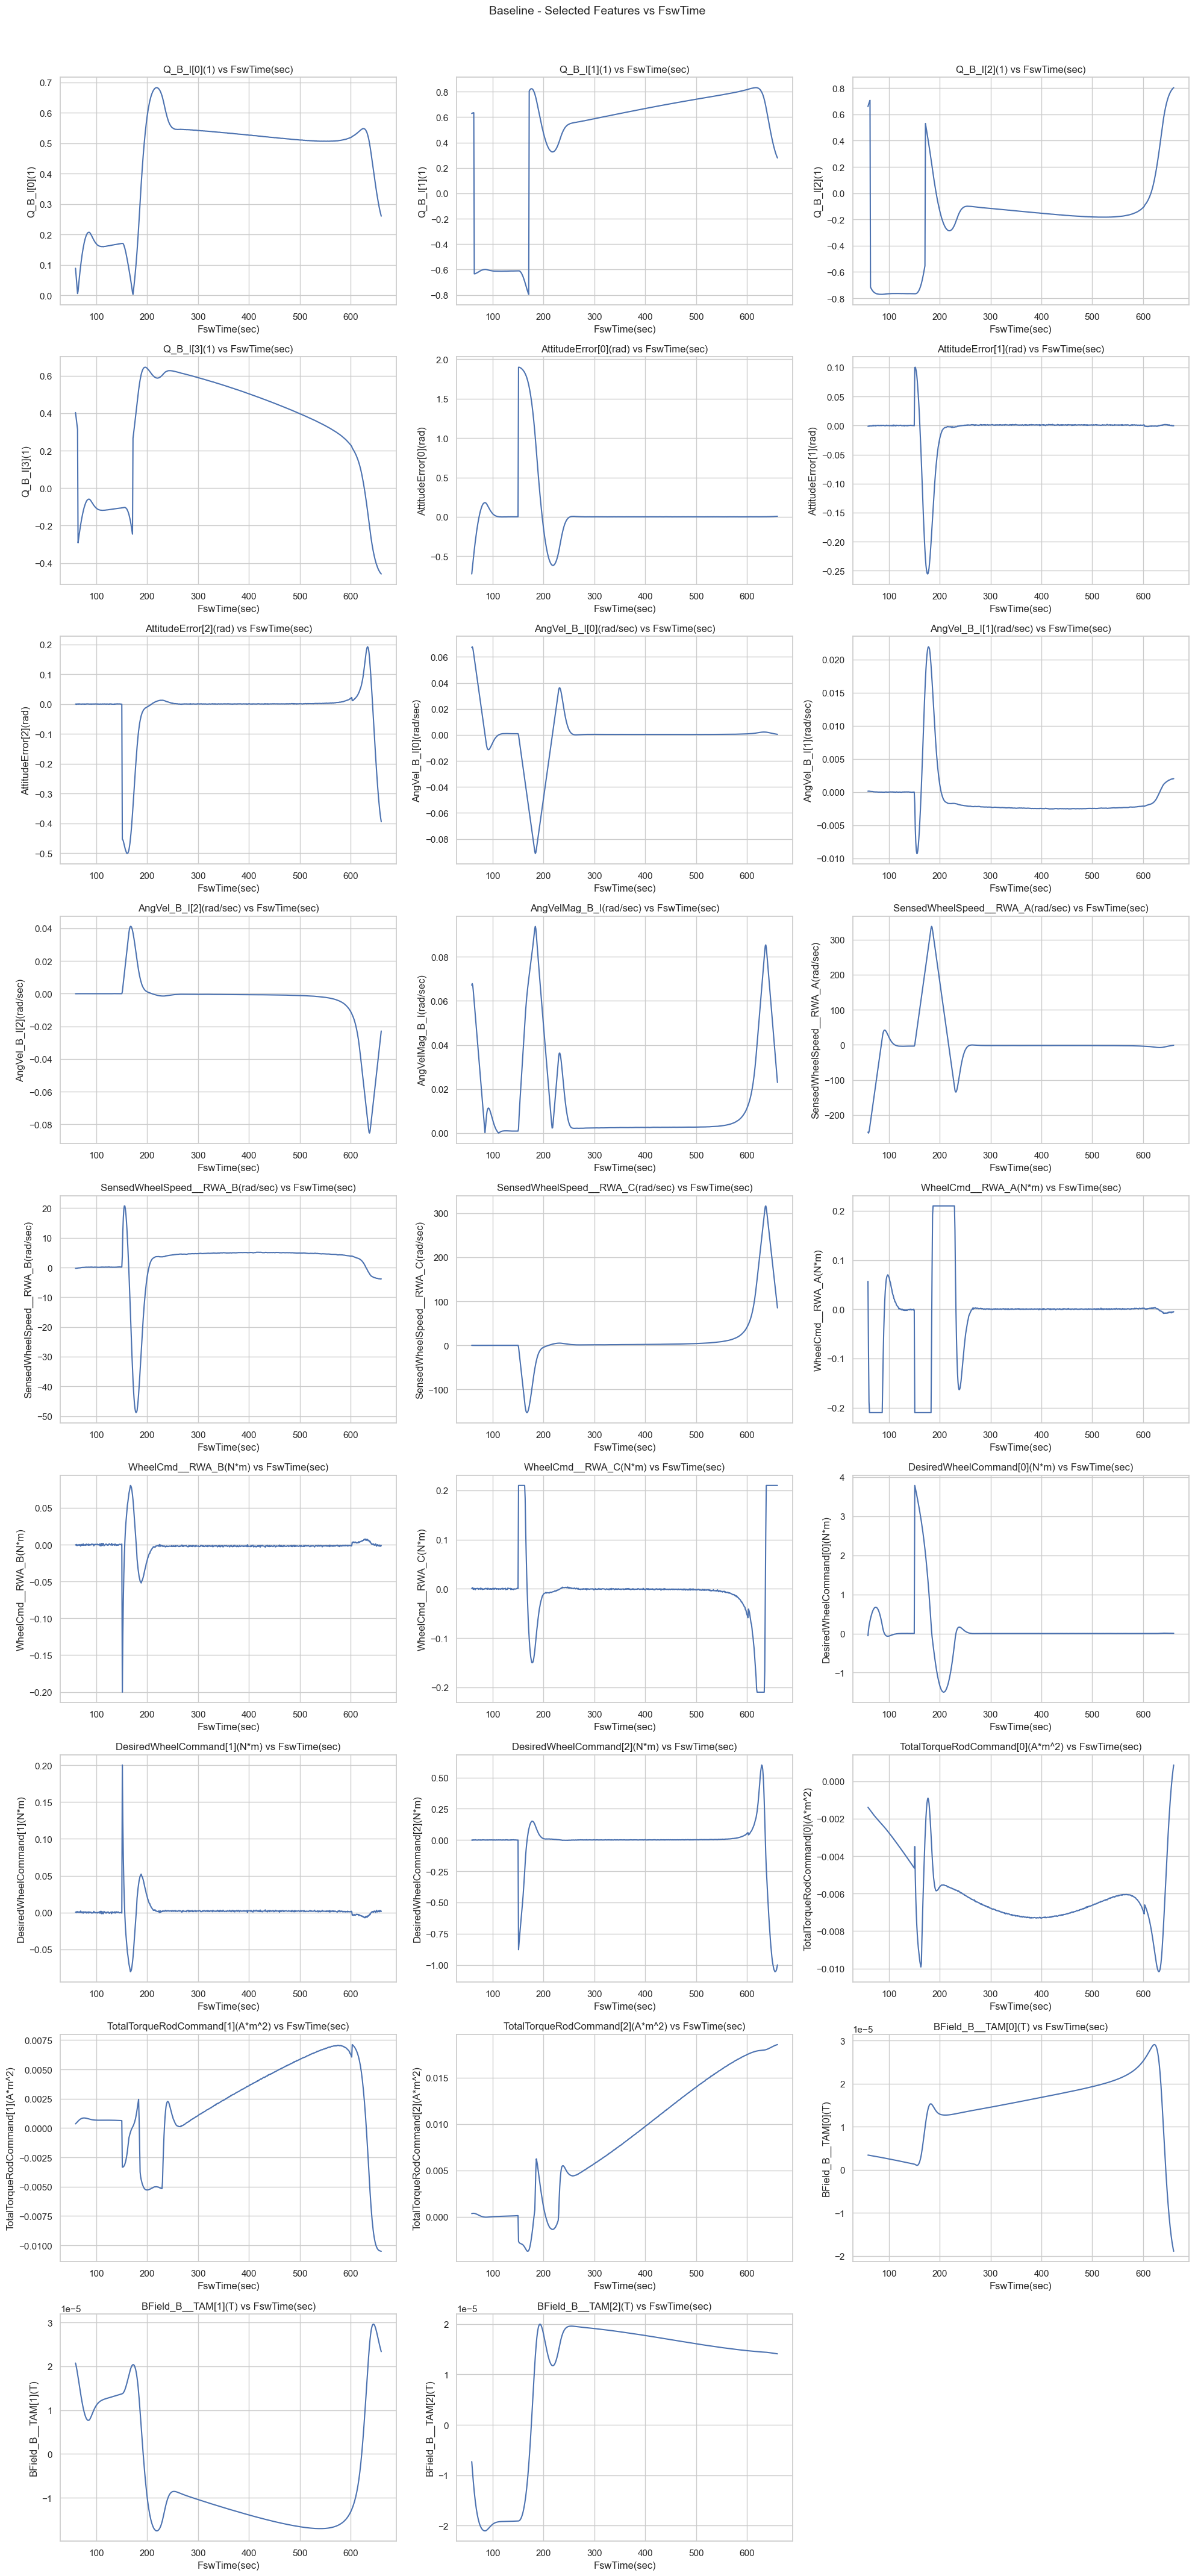

In [142]:
# Baseline örnek sample csv dosyası seçilmiş feature'ların fsw time a karşı zaman serisi görselleştirmesi:

plot_features_vs_time(sample_baseline_ts_df, title="Baseline - Selected Features vs FswTime")

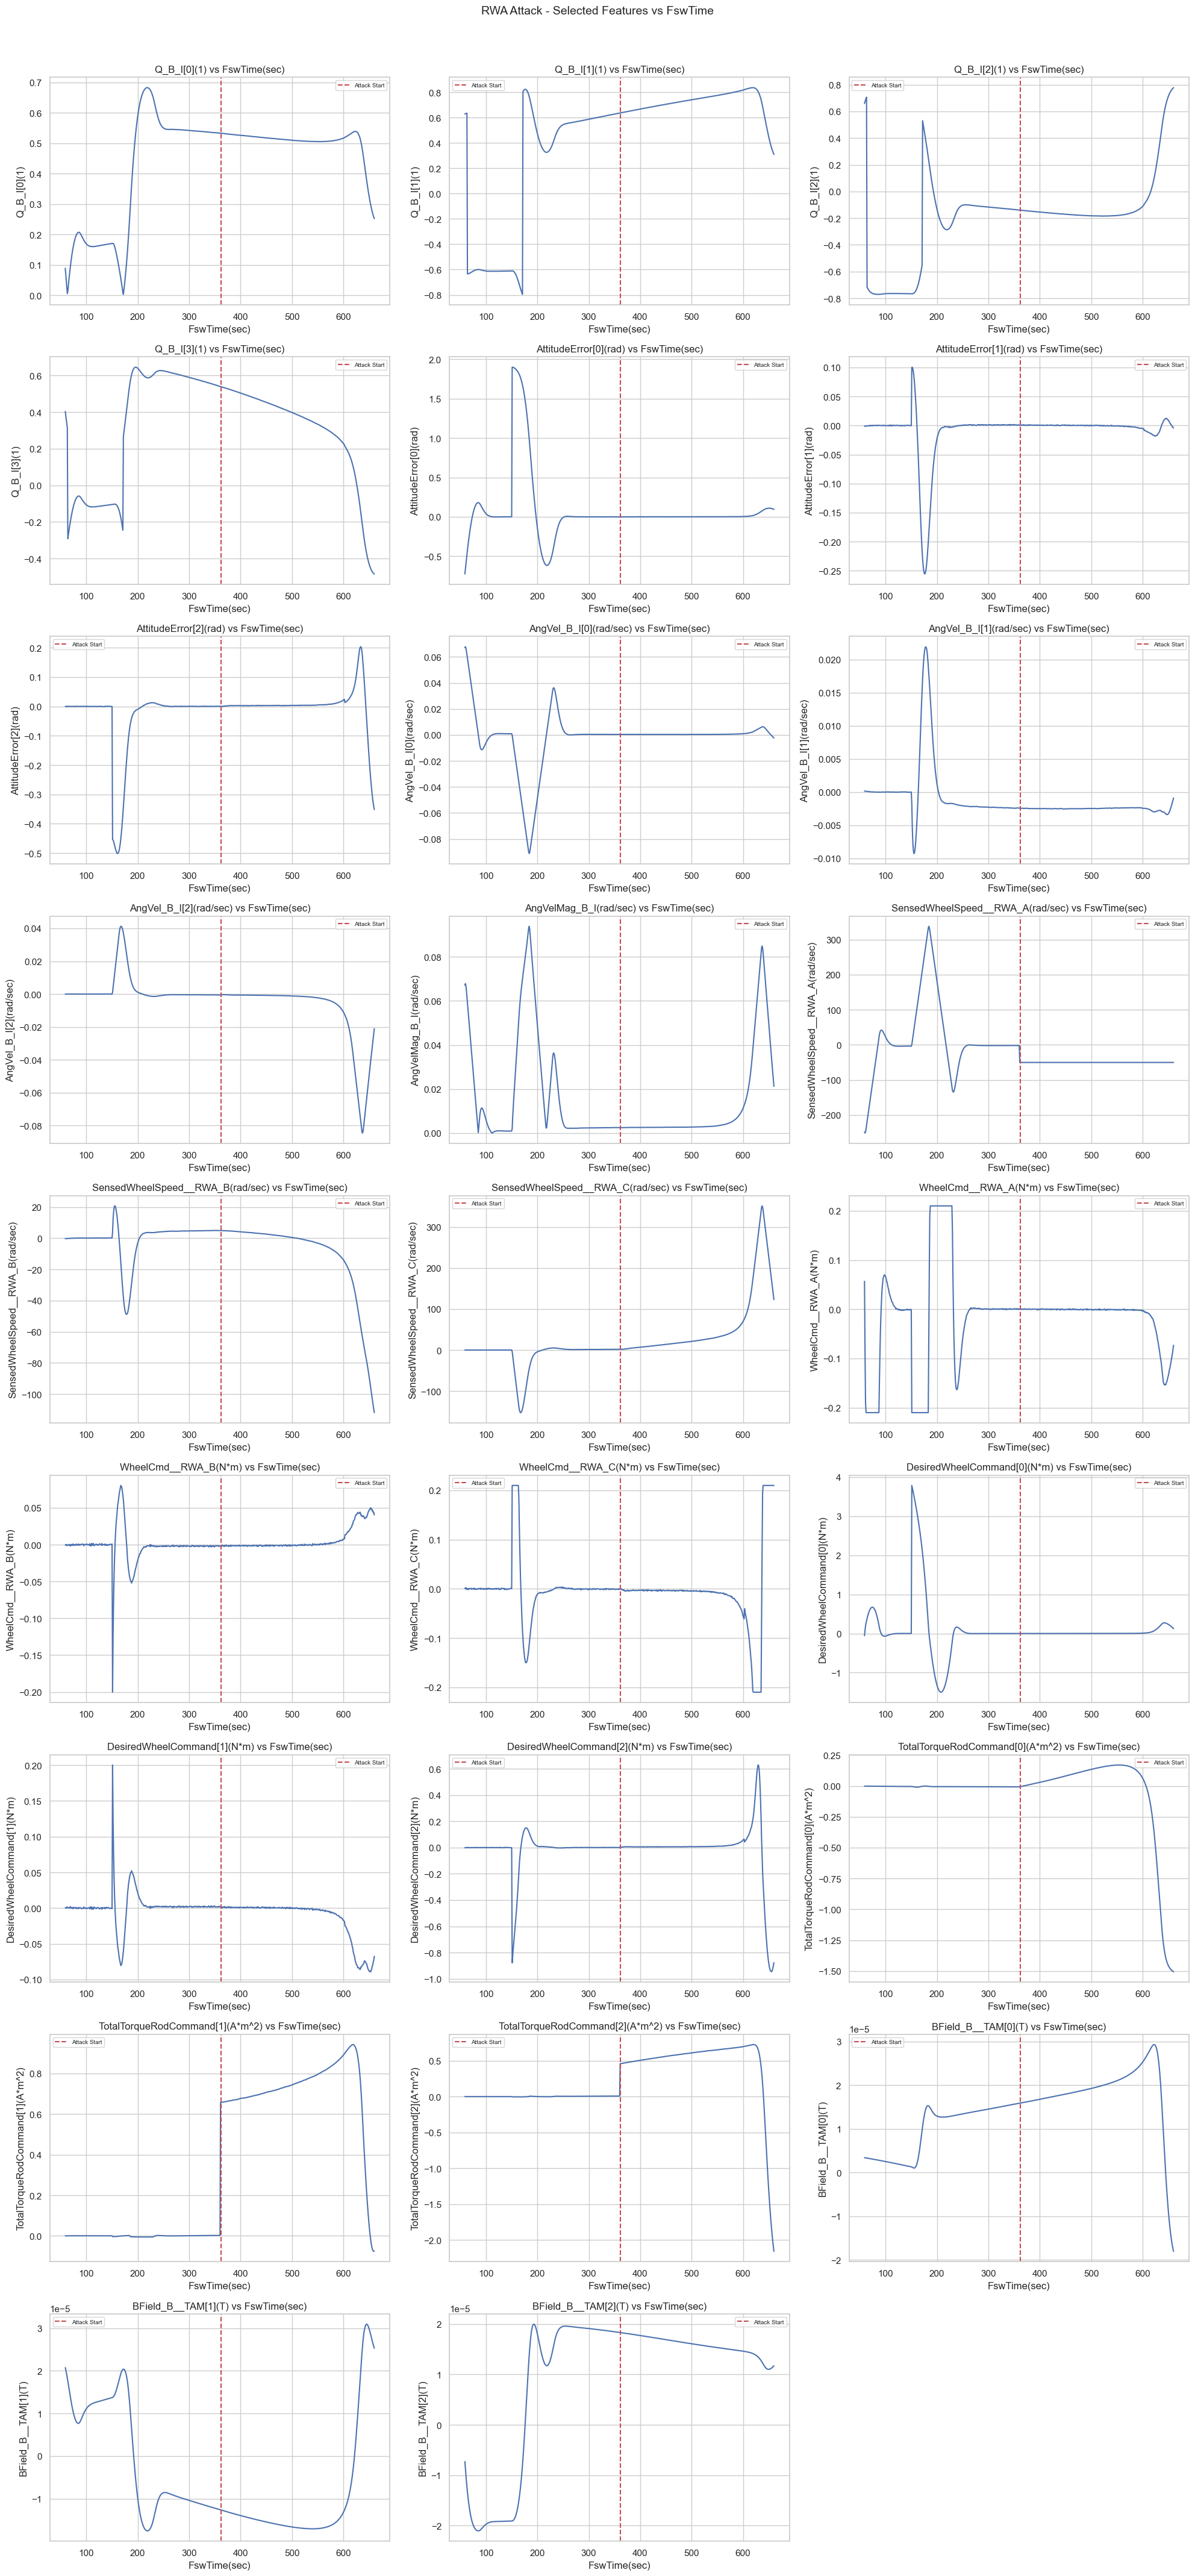

In [143]:
# attack_rwa örnek sample csv dosyası seçilmiş feature'ların fsw time a karşı zaman serisi görselleştirmesi:

plot_features_vs_time(sample_attackrwa_ts_df, title="RWA Attack - Selected Features vs FswTime", attack_time=362)


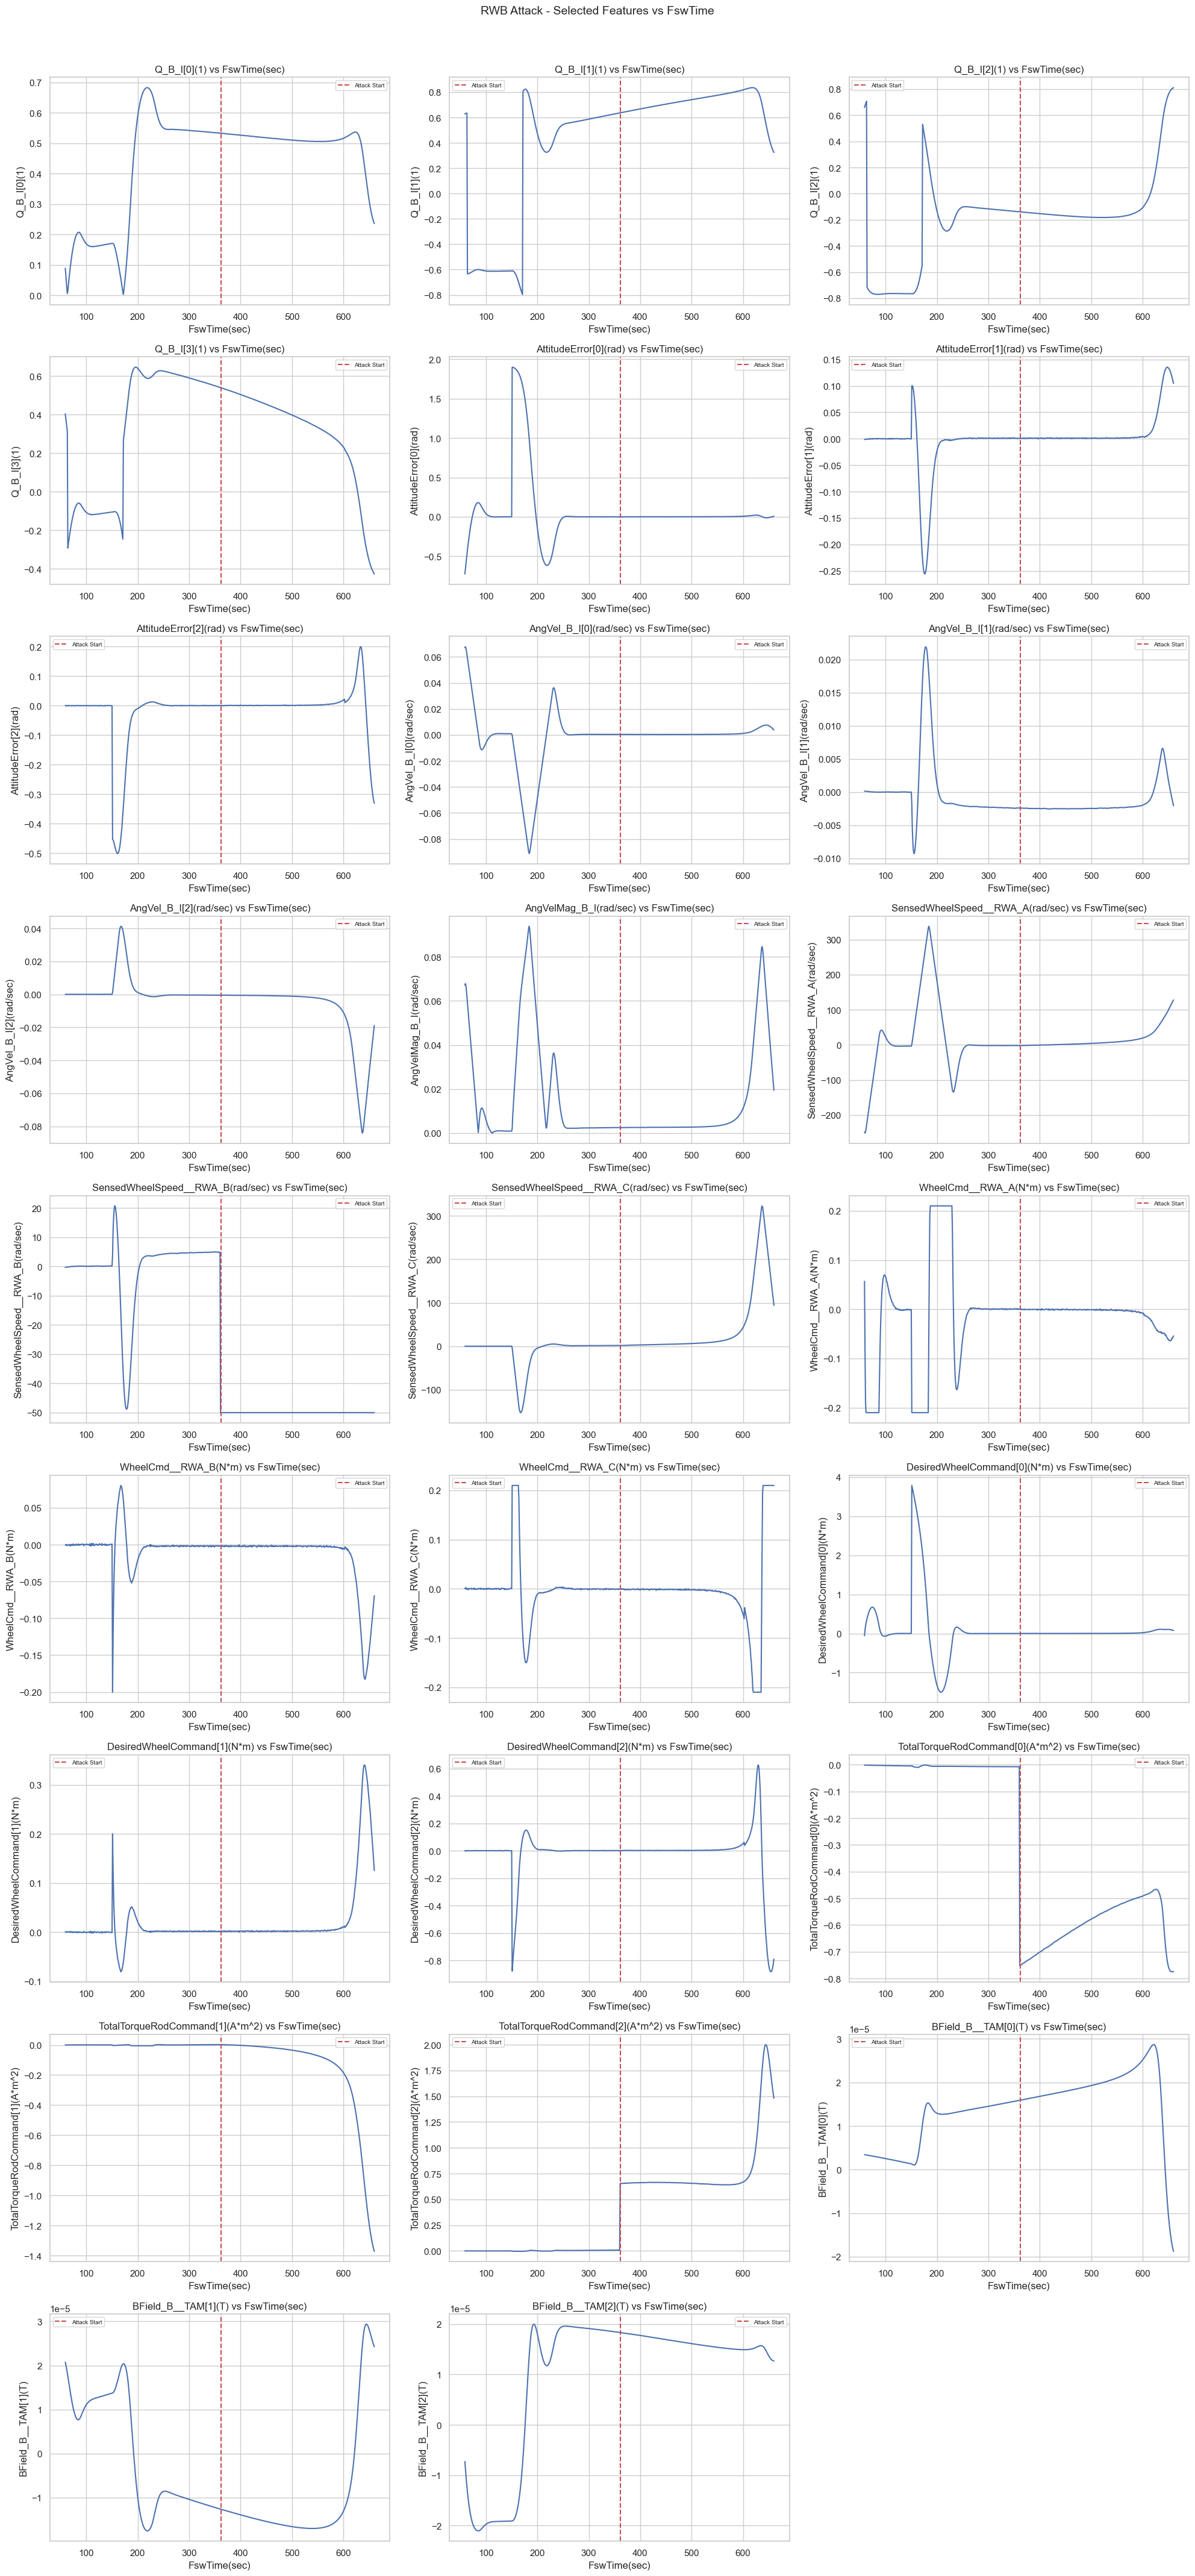

In [146]:
# attack_rwb örnek sample csv dosyası seçilmiş feature'ların fsw time a karşı zaman serisi görselleştirmesi:

plot_features_vs_time(sample_attackrwb_ts_df, "RWB Attack - Selected Features vs FswTime", attack_time=362)

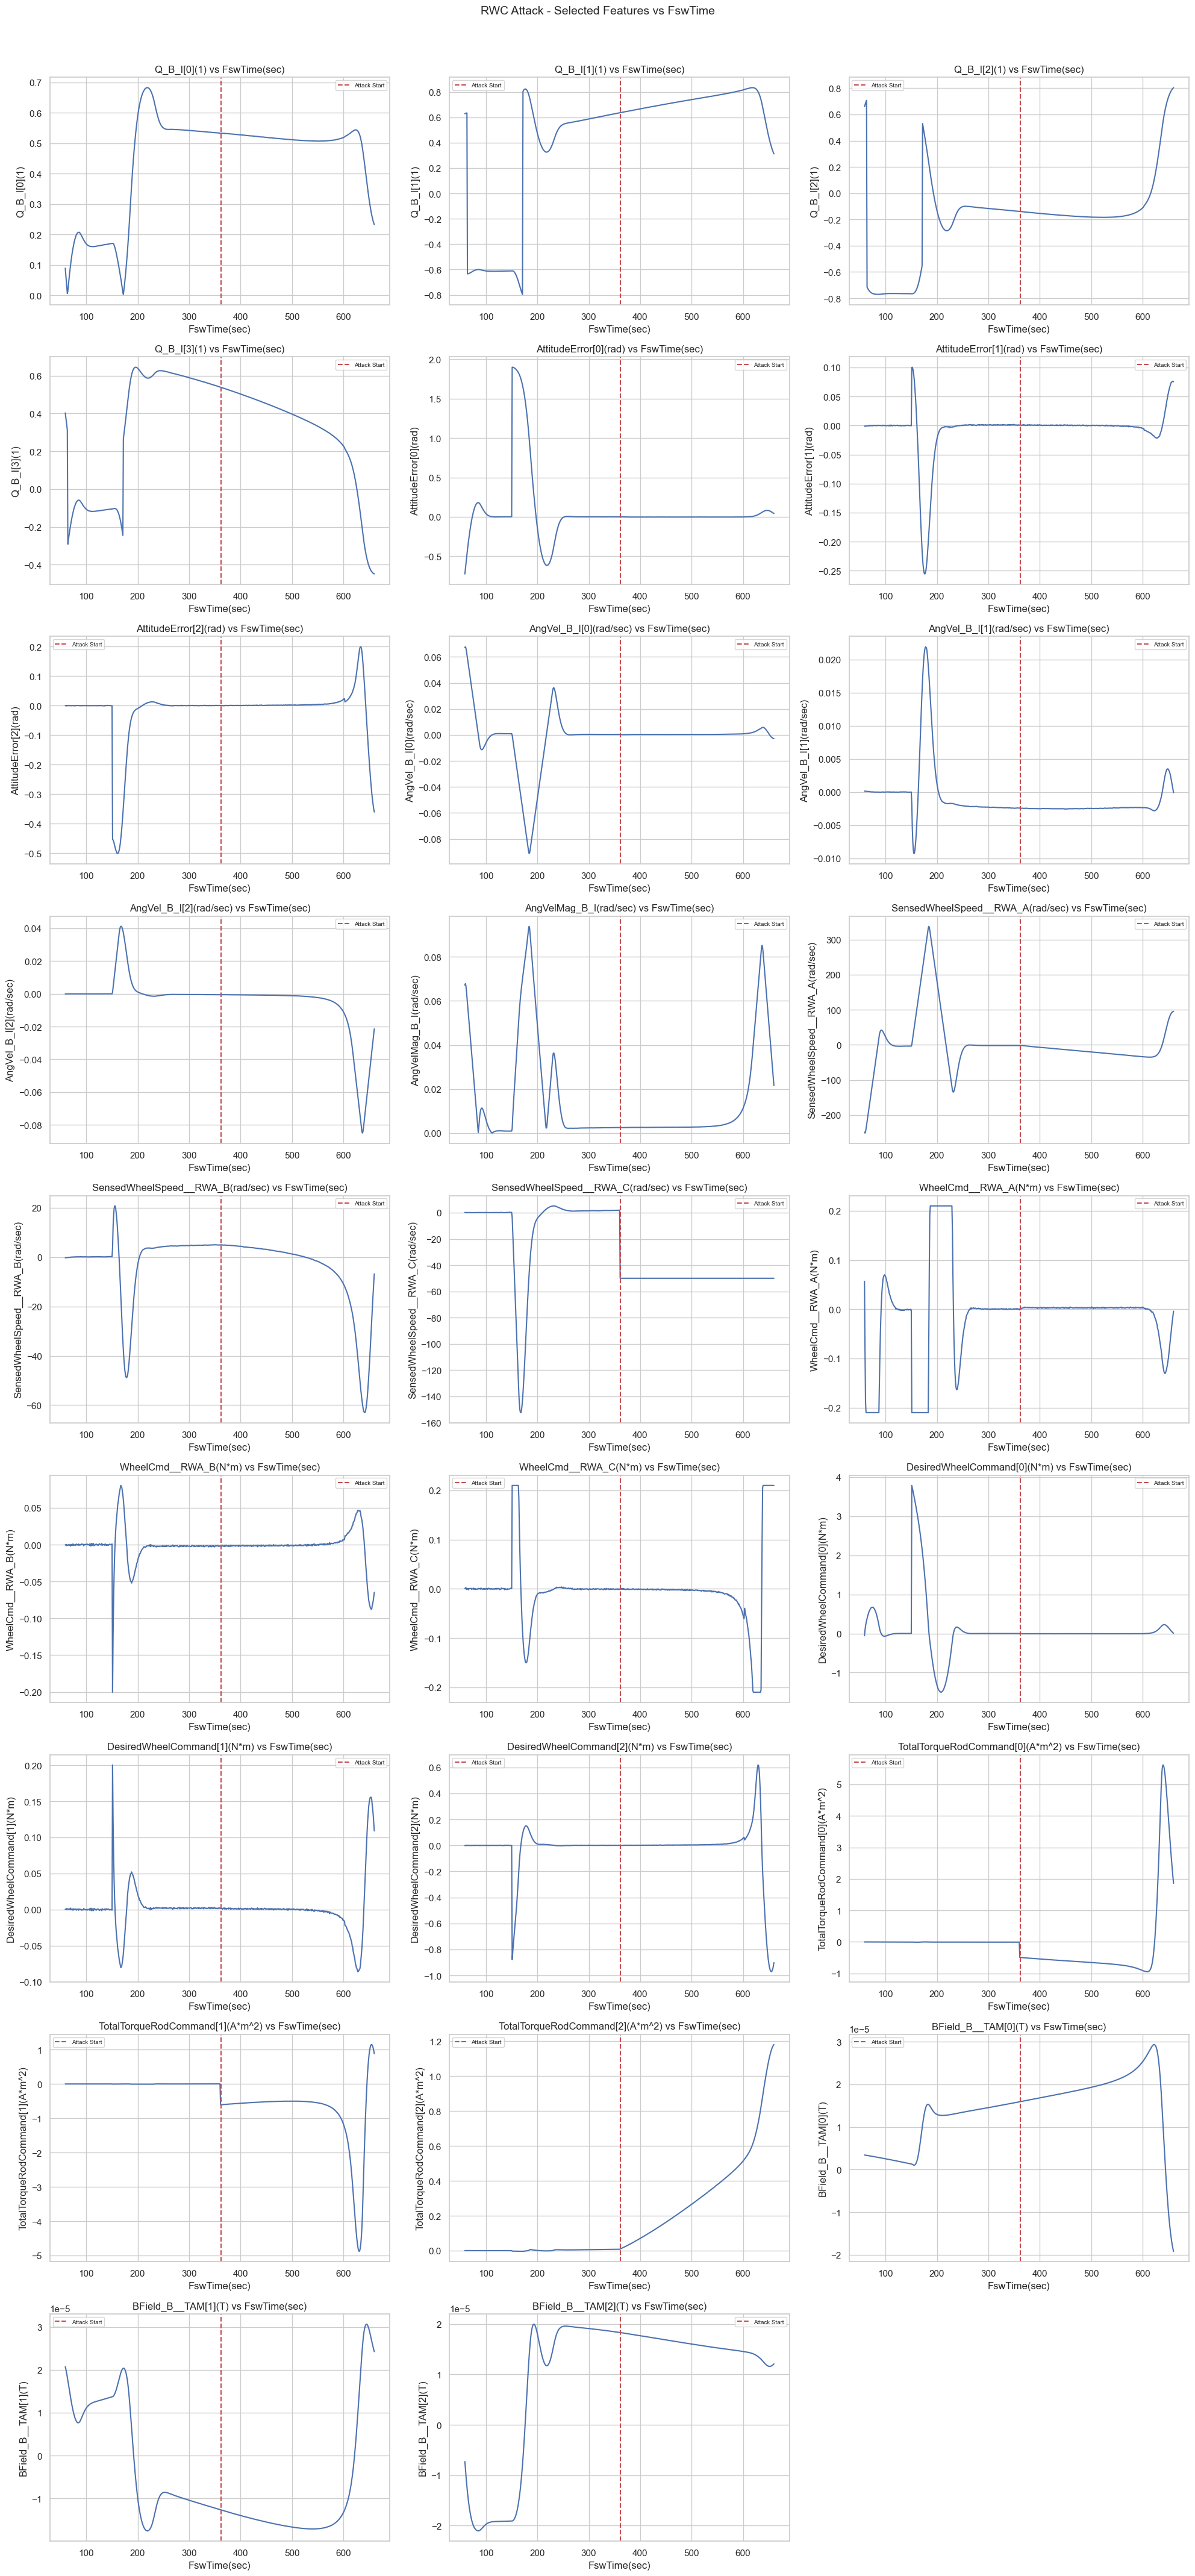

In [147]:
# attack_rwc örnek sample csv dosyası seçilmiş feature'ların fsw time a karşı zaman serisi görselleştirmesi:

plot_features_vs_time(sample_attackrwc_ts_df, "RWC Attack - Selected Features vs FswTime", attack_time=362)